# RabTech Academy — Task 05
## Deep Learning / NLP Text Classifier with TensorFlow
### Movie Review Sentiment Classification

**Pipeline:** text → TF-IDF → multi-layer neural network → POSITIVE/NEGATIVE + confidence.

Includes Batch Normalization, Dropout, Early Stopping, convergence curves, test evaluation and unseen-text inference.


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import joblib

SEED=42
np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow:", tf.__version__)


TensorFlow: 2.20.0


## 1. Load and decode the Keras IMDB dataset

In [2]:
VOCAB_LIMIT=20000
(x_seq,y_full),(x_test_seq,y_test)=keras.datasets.imdb.load_data(num_words=VOCAB_LIMIT)
word_index=keras.datasets.imdb.get_word_index()
reverse={i+3:w for w,i in word_index.items()}
reverse.update({0:"<PAD>",1:"<START>",2:"<UNK>",3:"<UNUSED>"})

def decode(seq):
    return " ".join(reverse.get(i,"<UNK>") for i in seq if i>3)

texts=[decode(s) for s in x_seq]
test_texts=[decode(s) for s in x_test_seq]
print(len(texts), "training reviews;", len(test_texts), "test reviews")
print(texts[0][:600])


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
25000 training reviews; 25000 test reviews
this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert is an amazing actor and now the same being director father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what


## 2. Training/validation split

In [3]:
train_texts,val_texts,y_train,y_val=train_test_split(
    texts,y_full,test_size=.20,random_state=SEED,stratify=y_full)
print(len(train_texts),len(val_texts),len(test_texts))


20000 5000 25000


## 3. TF-IDF — fitted on training text only

In [4]:
MAX_FEATURES=10000
vectorizer=TfidfVectorizer(max_features=MAX_FEATURES,ngram_range=(1,2),
                           min_df=2,max_df=.95,sublinear_tf=True,dtype=np.float32)
X_train=vectorizer.fit_transform(train_texts)
X_val=vectorizer.transform(val_texts)
X_test=vectorizer.transform(test_texts)
print(X_train.shape,X_val.shape,X_test.shape)


(20000, 10000) (5000, 10000) (25000, 10000)


In [7]:
# Convert sparse TF-IDF matrices to dense arrays for TensorFlow
X_train = X_train.toarray().astype("float32")
X_val = X_val.toarray().astype("float32")
X_test = X_test.toarray().astype("float32")

print("X_train:", X_train.shape, X_train.dtype)
print("X_val:", X_val.shape, X_val.dtype)
print("X_test:", X_test.shape, X_test.dtype)

X_train: (20000, 10000) float32
X_val: (5000, 10000) float32
X_test: (25000, 10000) float32


## 4. Multi-layer neural network with Batch Normalization and Dropout

In [5]:
model=keras.Sequential([
    layers.Input(shape=(MAX_FEATURES,)),
    layers.Dense(256,activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(.50),
    layers.Dense(128,activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(.40),
    layers.Dense(64,activation="relu"),
    layers.Dropout(.30),
    layers.Dense(1,activation="sigmoid")
])
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",metrics=["accuracy"])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     2,560,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,603,009 (9.93 MB)

 Trainable params: 2,602,241 (9.93 MB)

 Non-trainable params: 768 (3.00 KB)

## 5. Train with Early Stopping

In [8]:
early=keras.callbacks.EarlyStopping(monitor="val_loss",patience=3,
                                           restore_best_weights=True,verbose=1)
history=model.fit(X_train,y_train,validation_data=(X_val,y_val),
                  epochs=20,batch_size=128,callbacks=[early],verbose=1)


Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.8070 - loss: 0.4315 - val_accuracy: 0.7428 - val_loss: 0.6025
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.9173 - loss: 0.2090 - val_accuracy: 0.8772 - val_loss: 0.3844
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.9499 - loss: 0.1338 - val_accuracy: 0.8720 - val_loss: 0.3054
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 0.9706 - loss: 0.0805 - val_accuracy: 0.8650 - val_loss: 0.4384
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.9787 - loss: 0.0584 - val_accuracy: 0.8684 - val_loss: 0.5371
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.9841 - loss: 0.0428 - val_accuracy: 0.8690 - val_loss: 0.6182
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


## 6. Loss and accuracy convergence curves

,accuracy,loss,val_accuracy,val_loss
0,0.80705,0.431466,0.7428,0.602462
1,0.91735,0.209003,0.8772,0.384431
2,0.94990,0.133752,0.8720,0.305377
3,0.97055,0.080532,0.8650,0.438364
4,0.97870,0.058355,0.8684,0.537051
5,0.98410,0.042835,0.8690,0.618178


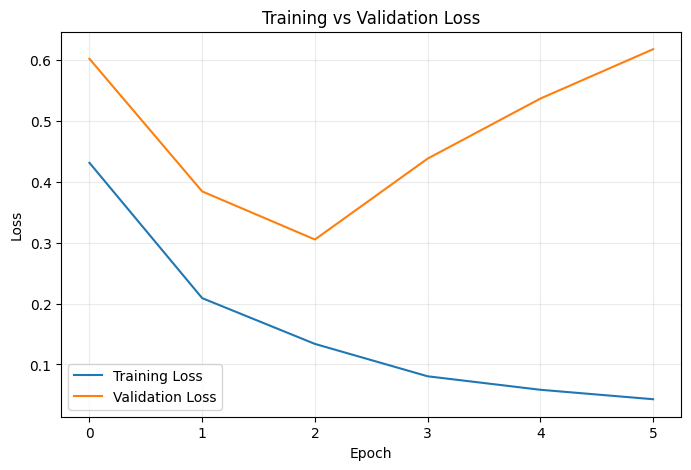

In [9]:
pd.DataFrame(history.history).display() if hasattr(pd.DataFrame(history.history),'display') else display(pd.DataFrame(history.history))
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Training vs Validation Loss")
plt.legend(); plt.grid(alpha=.25); plt.show()


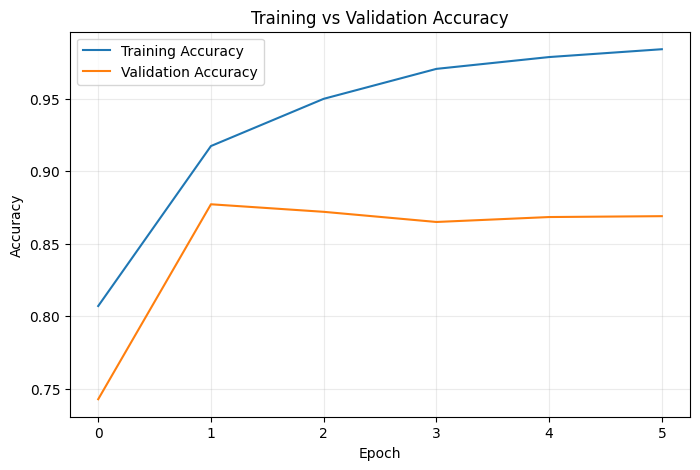

In [10]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Training vs Validation Accuracy")
plt.legend(); plt.grid(alpha=.25); plt.show()


## 7. Held-out test evaluation

Test loss: 0.3136
Test accuracy: 0.8640
              precision    recall  f1-score   support

    NEGATIVE     0.8266    0.9212    0.8713     12500
    POSITIVE     0.9110    0.8067    0.8557     12500

    accuracy                         0.8640     25000
   macro avg     0.8688    0.8640    0.8635     25000
weighted avg     0.8688    0.8640    0.8635     25000



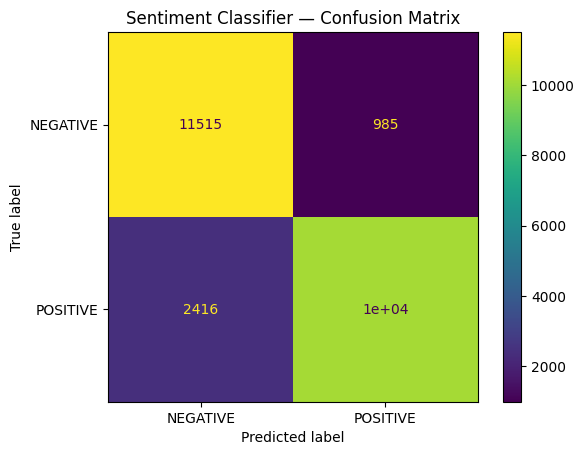

In [11]:
loss,acc=model.evaluate(X_test,y_test,verbose=0)
prob=model.predict(X_test,batch_size=256,verbose=0).ravel()
pred=(prob>=.5).astype(int)
print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {acc:.4f}")
print(classification_report(y_test,pred,target_names=["NEGATIVE","POSITIVE"],digits=4))
ConfusionMatrixDisplay(confusion_matrix(y_test,pred),
                       display_labels=["NEGATIVE","POSITIVE"]).plot()
plt.title("Sentiment Classifier — Confusion Matrix"); plt.show()


## 8. Unseen text inference with confidence

In [12]:
def predict_sentiment(text):
    p=float(model.predict(vectorizer.transform([text]),verbose=0)[0][0])
    label="POSITIVE" if p>=.5 else "NEGATIVE"
    confidence=p if p>=.5 else 1-p
    return {"text":text,"prediction":label,"confidence_percent":round(confidence*100,2)}

samples=[
"This movie was absolutely amazing. The acting was brilliant and I loved every minute.",
"I hated this film. The story was boring and a complete waste of time.",
"The movie had some good moments, but overall it was disappointing.",
"Fantastic performances and a beautiful story. I would definitely watch it again."
]
display(pd.DataFrame([predict_sentiment(x) for x in samples]))


,text,prediction,confidence_percent
0,This movie was absolutely amazing. The acting ...,POSITIVE,98.60
1,I hated this film. The story was boring and a ...,NEGATIVE,99.89
2,"The movie had some good moments, but overall i...",NEGATIVE,89.47
3,Fantastic performances and a beautiful story. ...,POSITIVE,98.34


In [13]:
my_review="The story was engaging and the performances were excellent."
r=predict_sentiment(my_review)
print("Text:",r["text"])
print("Prediction:",r["prediction"])
print(f'Confidence: {r["confidence_percent"]}%')


Text: The story was engaging and the performances were excellent.
Prediction: POSITIVE
Confidence: 67.79%


## 9. Save trained artifacts

In [14]:
model.save("sentiment_model.keras")
joblib.dump(vectorizer,"tfidf_vectorizer.joblib")
print("Saved sentiment_model.keras")
print("Saved tfidf_vectorizer.joblib")


Saved sentiment_model.keras
Saved tfidf_vectorizer.joblib


## Conclusion
The project implements the required TF-IDF NLP pipeline and a multi-layer TensorFlow network with Batch Normalization, Dropout and Early Stopping. The notebook reports training/validation convergence and demonstrates predictions with confidence on unseen text.

**Leakage control:** TF-IDF is fitted only on training text; the official test set is held out until final evaluation.

**Limitation:** sentiment is context-dependent and confidence scores are not certainty.
